# **Clasificador con BERT**

#### Óscar Niño Robles

## **¡Elección del dataset!**

 Me voy a enfrentar a un problema de **clasificación multietiqueta** en el que analizaremos textos y tenemos que detetectar si son comentarios tóxicos o no y que tipo de toxicidad (insultos, amenazas, obscenidades...) es la que se incluye en los mismos


El dataset viene de la competición [Jigsaw Toxic Comment Classification](https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge). Como hemos dicho antes es un dataset con clasificacion multietiqueta así que el mismo comentarios puede pertenecer a una, varias o ninguna clase (que serían los sanos).

**Justificación del Dataset**: He escogido este dataset en parte para llevarme la experiencia no solo de entrenar un modelo con BERT si no también de añadirle una dificultad extra el problema y experimentar un problema de clasificación multietiqueta, que personalmente no lo había hecho nunca. Y bueno, por supuesto me gusta la temática, me parece mucho más interesante que el típico dataset de reviews y decir si son positivas o negativas.

##  **Conociendo los datos**

 Pequeño análisis exploratorio: cuántos ejemplos hay, cómo están distribuidas las clases, qué pinta tienen los textos ...



In [ ]:
#Importamos algunas librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

Los datos cuentan con la columna **comment_text** que sería el texto que vamos a usar y las columnas **toxic, severe_toxic, obscene, threat, insult, identity_hate** que son las clases. Recordemos que un ejemplo puede no tener ninguna clase asignada y ser un comentario sano, o puede que tenga varias clases (un comentario puede ser racista y amenazador por ejemplo).

Lo primero que haremos será cargar el dataset

In [ ]:
# Cargar el dataset directamente desde Hugging Face
dataset = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge", split="train")

# Convertir a Pandas DataFrame
df = dataset.to_pandas()

# Ver las dimensiones y las primeras filas
print(f"Número total de comentarios: {df.shape[0]}")
display(df.head())

README.md:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv:   0%|          | 0.00/4.98M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

Número total de comentarios: 159571


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Vemos que los primeros comentarios son todos sanos, intentamos imprimir algunos comentarios que no lo sean también.

In [ ]:
# Definimos las etiquetas de nuevo para asegurar
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Filtramos el DataFrame original para quedarnos SOLO con filas donde la suma de las etiquetas sea mayor que 0
df_con_categorias = df[df[labels].sum(axis=1) > 0]

print(f"Total de comentarios con al menos una categoría activa: {df_con_categorias.shape[0]}")

# Mostramos los primeros 5 ejemplos incluyendo el texto y sus etiquetas correspondientes
display(df_con_categorias[['comment_text'] + labels].head())

# Si quisieramos ver un ejemplo específico de una clase rara como 'threat' (amenaza):
# df_amenazas = df[df['threat'] == 1]
# display(df_amenazas[['comment_text', 'threat']].head())


Total de comentarios con al menos una categoría activa: 16225


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
12,Hey... what is it..\n@ | talk .\nWhat is it......,1,0,0,0,0,0
16,"Bye! \n\nDon't look, come or think of comming ...",1,0,0,0,0,0
42,You are gay or antisemmitian? \n\nArchangel WH...,1,0,1,0,1,1
43,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",1,0,1,0,1,0


O si sacamos una muestra donde se vean ejemplos de ambos tipos

In [ ]:
# Sacamos 5 comentarios 100% limpios
df_limpios = df[(df[labels] == 0).all(axis=1)].sample(5, random_state=42)

# Sacamos 5 comentarios con al menos alguna toxicidad
df_toxicos = df[df[labels].sum(axis=1) > 0].sample(5, random_state=42)

# Los unimos (concat) y los barajamos (sample(frac=1))
df_mixto = pd.concat([df_limpios, df_toxicos]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Muestra mixta de comentarios (Sanos y Tóxicos):")
display(df_mixto[['comment_text'] + labels])

Muestra mixta de comentarios (Sanos y Tóxicos):


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,DUMB ASSES\nIt's was my sockpuppet...joe hazet...,1,0,0,0,0,0
1,Are you trying to dispute that fact?,0,0,0,0,0,0
2,"""\nI was talking about them running any check ...",1,0,0,0,0,0
3,"""\n\nOh, don't worry about me, Sandstein. I'm ...",0,0,0,0,0,0
4,eat shit get rid of goofs you queers.,1,0,1,0,1,0
5,SWOT analysis \n\nThis source – Align Technolo...,0,0,0,0,0,0
6,"Are all professors of rhetoric pompous, self-c...",1,0,1,0,1,0
7,P.S. It's probably worth setting up a template...,0,0,0,0,0,0
8,"cover \n\nso, do we want a current or older co...",0,0,0,0,0,0
9,White Trash\nFuck off you white piece of trash...,1,1,1,0,1,1


Lo primero que nos viene a la mente es pensar ¿cómo se organiza el dataset? ¿quizás es **toxic** una superclase y tiene que estar siempre activa si un mensaje no es sano y luego entre las otras clases hay que clasificar el tipo de toxicidad? En los pocos ejemplos que hemos sacado por pantalla desde luego lo parece, para comprobar esto vamos a ver si hay instancias en las que la categoría *toxic* sea 0 y esté activa alguna de las otras.

In [ ]:
# Buscamos comentarios donde 'toxic' es 0, pero la suma del resto de etiquetas es mayor que 0
anomalias = df[(df['toxic'] == 0) & (df[['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum(axis=1) > 0)]

print(f"Comentarios anómalos (no 'toxic', pero con otras etiquetas activas): {anomalias.shape[0]}")
if anomalias.shape[0] > 0:
    display(anomalias[['comment_text'] + labels].head(3))

Comentarios anómalos (no 'toxic', pero con otras etiquetas activas): 931


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
179,"REPLY ABOVE:\nThat was me, loser. The UN defin...",0,0,0,0,1,0
527,How do you know he is dead. Its just his plan...,0,0,1,0,0,0
662,Hebrew Name of Lydia \nAppologies to Til Eulen...,0,0,0,0,1,0


Realmente solo hay 931 ejemplos de entre 159571 que no tienen la clase *toxic* activa pero sí alguna de las otras. Parece más un error de etiquetado de los datos que otra cosa pues solo representan un 0.006% de los datos. Igualmente, nosotros asumiremos que no es una superclase y las trataremos todas de forma independiente.

**NOTA:** Si quisieramos asumir que *toxic* es una super clase y que siempre tiene que ser positivo para que alguna de las otras clases sea positiva también, podríamos hacer dos modelos uno que solo clasifique el comentario como tóxico o no, y luego otro que vea qué tipos de toxicidades (ya sabendo que el comentario es tóxico) incluye el mismo. Esto se podría considerar trabajo futuro pues creo que excede a lo que se espera de este trabajo, intuyo que simplemente ver este patrón y reflejar que se ha tenido en cuenta de alguna forma es suficiente. En este caso, como estaríamos considerando que esos ejemplos están "mal etiquetados" los podríamos eliminar, cosa que nosotros no haremos.

Ahora pasamos a ver el balance de clases, para ello se hace simplemente clase a clase de forma natural aunque el dataset sea multietiqueta

--- REPORTE DE DISTRIBUCIÓN (159571 comentarios en total) ---
TOXIC           | Conteo: 15294   | Porcentaje: 9.58%
SEVERE_TOXIC    | Conteo: 1595    | Porcentaje: 1.00%
OBSCENE         | Conteo: 8449    | Porcentaje: 5.29%
THREAT          | Conteo: 478     | Porcentaje: 0.30%
INSULT          | Conteo: 7877    | Porcentaje: 4.94%
IDENTITY_HATE   | Conteo: 1405    | Porcentaje: 0.88%
CLEAN           | Conteo: 143346  | Porcentaje: 89.83%
------------------------------------------------------------


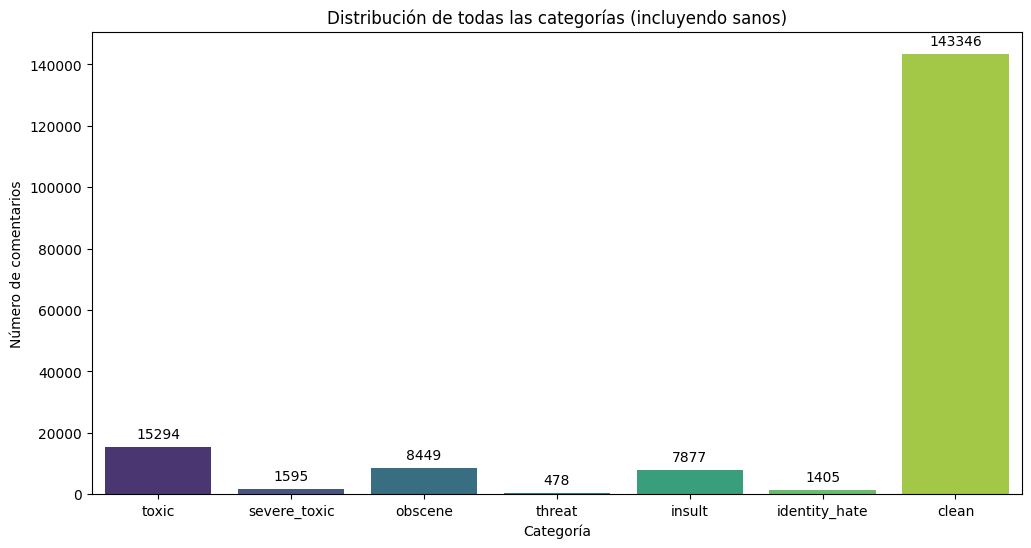

In [ ]:
# Definimos las etiquetas de toxicidad
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Creamos una columna temporal para los comentarios "sanos" (todo a 0)
df['clean'] = (df[labels] == 0).all(axis=1).astype(int)

# Lista con todas las categorías a analizar
todas_categorias = labels + ['clean']

# Calculamos el conteo total y el porcentaje por categoría
total_comentarios = df.shape[0]
conteo = df[todas_categorias].sum()
porcentajes = (conteo / total_comentarios) * 100

# Imprimimos el reporte en texto
print(f"--- REPORTE DE DISTRIBUCIÓN ({total_comentarios} comentarios en total) ---")
for cat in todas_categorias:
    print(f"{cat.upper():<15} | Conteo: {conteo[cat]:<7} | Porcentaje: {porcentajes[cat]:.2f}%")
print("-" * 60)

# Visualizamos en el gráfico de barras
plt.figure(figsize=(12, 6))
grafico = sns.barplot(
    x=conteo.index,
    y=conteo.values,
    hue=conteo.index,
    palette="viridis",
    legend=False
)

plt.title("Distribución de todas las categorías (incluyendo sanos)")
plt.ylabel("Número de comentarios")
plt.xlabel("Categoría")

# Añadir el número encima de cada barra
for p in grafico.patches:
    grafico.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.show()

El dataset está exagerdamente desbalanceado pues el 90% son sanos que son 143346 y solo 478 de amenazas (*threat*). Vamos a ignorar las sanas y ver solo el balance de las tóxicas para poder ver mejor la proporción entre ellas

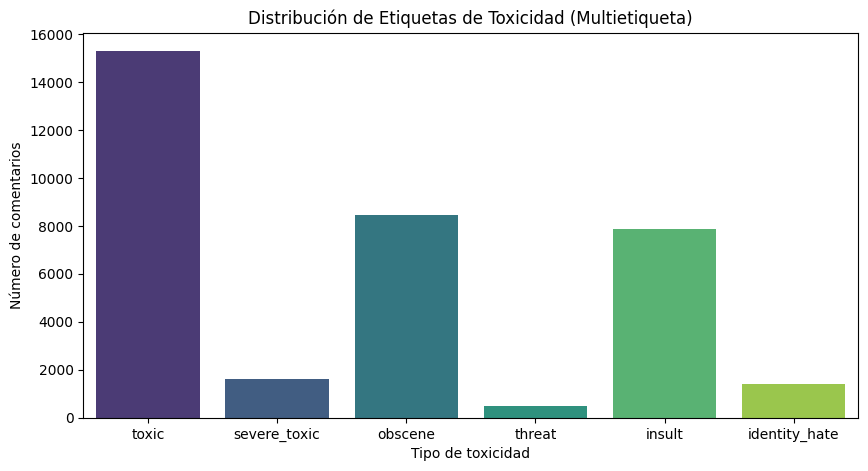


Comentarios sin ninguna etiqueta tóxica: 143346 (89.83%)


In [ ]:
# Definir las columnas de las etiquetas
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Sumar la cantidad de ejemplos positivos para cada clase
class_counts = df[labels].sum()

# Visualizar la distribución
plt.figure(figsize=(10, 5))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="viridis",
    legend=False
)
plt.title("Distribución de Etiquetas de Toxicidad (Multietiqueta)")
plt.ylabel("Número de comentarios")
plt.xlabel("Tipo de toxicidad")
plt.show()

# Ver cuántos comentarios son totalmente limpios
clean_comments = df[(df[labels] == 0).all(axis=1)].shape[0]
print(f"\nComentarios sin ninguna etiqueta tóxica: {clean_comments} ({(clean_comments/df.shape[0])*100:.2f}%)")

La minoría absoluta la tienen las amenazas, y la clase mayoritaria como ya se sabía es simplemente tóxico.

**Reflexión sobre las categorías**: Llama la atención que hay una categoría llamada *severe_toxic*, y cabe plantearse ¿dónde está el límite? ¿cuál es el paso entre tóxico y muy tóxico? No creo que los humanos lo tengamos muy claro, mucho menos como para intentar enseñarselo a una máquina. **Se sospecha que *severe_toxic* puede ser una categoría complicada** pues también es una clase minoritaria.

Sabiendo el balance de clases, veamos también la distribución de longitud de los comentarios.

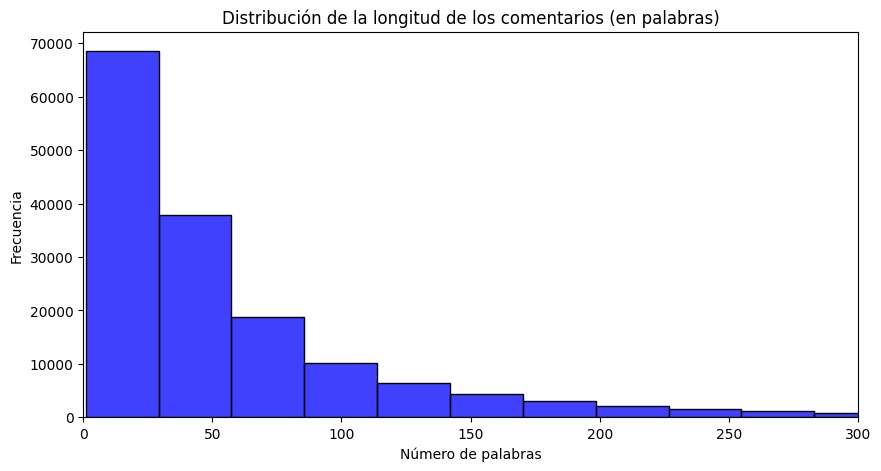

In [ ]:
# Calcular una estimación rápida de la longitud (por palabras)
df['word_count'] = df['comment_text'].apply(lambda x: len(str(x).split()))

# Visualizar la distribución de longitudes
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=False, color="blue")
plt.title("Distribución de la longitud de los comentarios (en palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.xlim(0, 300) # Recortamos la vista para ver el grueso de los datos
plt.show()

Vemos que hasta 150 de longitud aprox están la mayoría.

Pasamos a crear nuestro propio conjunto de datos, es evidente que no vamos a trabajar con los 160 mil ejemplo que trae el dataset. Esto se nos escaparía computacionalmente, requeriría mucho tiempo y además es obvio que no es el objetivo del trabajo. Para ello vamos a quedarnos solo con 20 mil ejemplos.

**División del dataset:** Aquí tenemos que hacer dos puntualizaciones, la primera es que no vas a hacer una división completamente estratificada pues vamos a aprovechar que el dataset está completamente desbalanceados para hacer **upsampling en los comentarios sanos**, es decir vamos a escoger menos de los que le tocaría al hacer muestreo estratificado para compensar los comentarios sanos y los tóxicos. Esto lo hacemos tomando 10 mil comentarios sanos y 10 mil comentarios tóxicos. De entre todos los comentarios que son de al menos una clase tóxica, no podemos elegir 10 mil al azar pues las clases minoritarias podrían desaparecer. Dentro de los que no son sanos sí que vamos a usar una divisón estratificada. Para ello vamos a usar la función `iterative_train_test_split` libreria `scikit-multilearn`que nos permite exactamente hacer eso, tomaremos 10 mil en el conjunto test y el conjunto de entrenamiento lo descartaremos. Se puede consultar más información sobre la librería [aquí](https://github.com/scikit-multilearn/scikit-multilearn/tree/master)

In [ ]:
!pip install scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
from skmultilearn.model_selection import iterative_train_test_split


# Separamos tóxicos y limpios del dataset original
df_toxicos = df[df[labels].sum(axis=1) > 0].copy()
df_limpios = df[(df[labels] == 0).all(axis=1)].copy()

# Submuestreo de limpios (Random puro, es seguro)
df_limpios_reducido = df_limpios.sample(n=10000, random_state=42)

# Submuestreo Estratificado de tóxicos
# Calculamos qué porcentaje de los tóxicos necesitamos para llegar a 10.000
proporcion_deseada = 10000 / len(df_toxicos)

X_toxicos = df_toxicos['comment_text'].values.reshape(-1, 1)
y_toxicos = df_toxicos[labels].values

# Forzamos la semilla de NumPy justo antes de la división
np.random.seed(42)
# La función parte los datos. Nos quedaremos con la partición "Test" porque le asignamos la proporción de 10.000
X_descarte, y_descarte, X_toxicos_10k, y_toxicos_10k = iterative_train_test_split(
    X_toxicos,
    y_toxicos,
    test_size=proporcion_deseada
)

# Reconstruimos el DataFrame con la muestra estratificada perfecta
df_toxicos_reducido = pd.DataFrame(y_toxicos_10k, columns=labels)
df_toxicos_reducido['comment_text'] = X_toxicos_10k.ravel()

# Juntamos, barajamos y reiniciamos el índice
df_final = pd.concat([df_toxicos_reducido, df_limpios_reducido])
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Tamaño del dataset final perfectamente estratificado: {df_final.shape[0]} filas.")

Tamaño del dataset final perfectamente estratificado: 20000 filas.


Vemos el balanceo de nuestros datos

--- BALANCEO DEL DATASET FINAL (Total: 20000) ---
Comentarios 100% limpios: 10000

Distribución de las etiquetas de toxicidad:
 - toxic          : 9426 (Aprox. 94.3% de la mitad tóxica)
 - severe_toxic   : 983 (Aprox. 9.8% de la mitad tóxica)
 - obscene        : 5207 (Aprox. 52.1% de la mitad tóxica)
 - threat         : 295 (Aprox. 2.9% de la mitad tóxica)
 - insult         : 4855 (Aprox. 48.5% de la mitad tóxica)
 - identity_hate  : 866 (Aprox. 8.7% de la mitad tóxica)


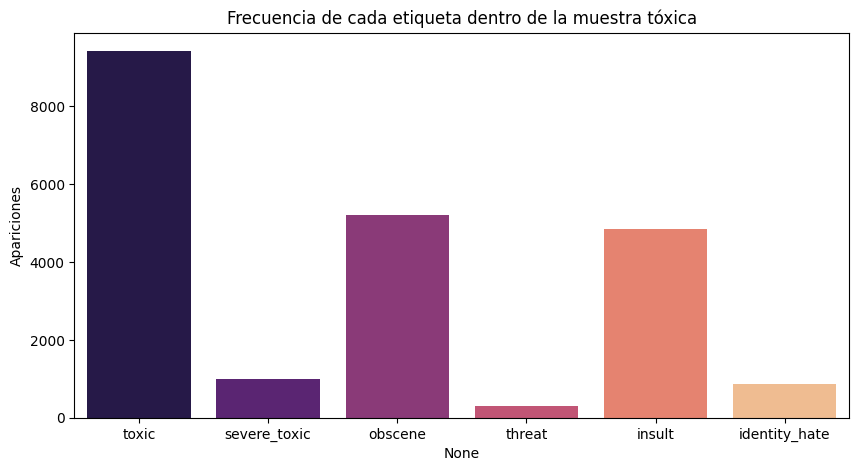

In [ ]:
# Contamos cuántos limpios hay (deberían ser exactamente 10.000)
num_limpios = df_final[(df_final[labels] == 0).all(axis=1)].shape[0]

# Sumamos las apariciones de cada etiqueta de toxicidad
conteo_etiquetas = df_final[labels].sum()

print(f"--- BALANCEO DEL DATASET FINAL (Total: {df_final.shape[0]}) ---")
print(f"Comentarios 100% limpios: {num_limpios}")
print("\nDistribución de las etiquetas de toxicidad:")
for etiqueta, cantidad in conteo_etiquetas.items():
    print(f" - {etiqueta:<15}: {cantidad} (Aprox. {(cantidad/10000)*100:.1f}% de la mitad tóxica)")

# Visualizamos solo las etiquetas de toxicidad para ver su proporción interna
plt.figure(figsize=(10, 5))
grafico = sns.barplot(
    x=conteo_etiquetas.index,
    y=conteo_etiquetas.values,
    hue=conteo_etiquetas.index,
    palette="magma",
    legend=False
)
plt.title("Frecuencia de cada etiqueta dentro de la muestra tóxica")
plt.ylabel("Apariciones")
plt.show()

Como ya tenemos nuestro dataset preparado, vamos a estudiar la longitud de nuestro dataset para poder establecer una longitud máxima al tokenizar. Metodológicamente, esto se debería hacer una vez separados los conjuntos en train,val,test (*holdout*) para evitar *data leakage*, pero como eso es la tarea 3, decidimos preservar el orden del trabajo pues tampoco variarán mucho los resultados.

Añadiremos una línea roja en el percentil 95 de la longitud de los textos, para tener una idea de donde podemos cortar a la hora de tokenizar.

--- ESTADÍSTICAS DE LONGITUD (En palabras) ---
Media de palabras:       61.0
Mediana de palabras:     29.0
Percentil 95:            213 palabras
Máximo de palabras:      1411


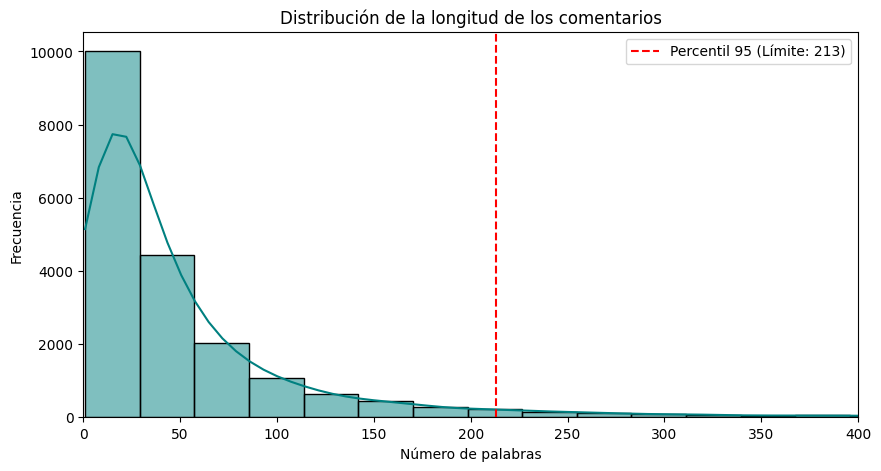

In [ ]:
# Calculamos la longitud en palabras de cada comentario
df_final['word_count'] = df_final['comment_text'].apply(lambda x: len(str(x).split()))

# Extraemos las estadísticas clave (¡incluyendo el percentil 95!)
media_palabras = df_final['word_count'].mean()
mediana_palabras = df_final['word_count'].median()
percentil_95 = int(df_final['word_count'].quantile(0.95))
max_palabras = df_final['word_count'].max()

print("--- ESTADÍSTICAS DE LONGITUD (En palabras) ---")
print(f"Media de palabras:       {media_palabras:.1f}")
print(f"Mediana de palabras:     {mediana_palabras:.1f}")
print(f"Percentil 95:            {percentil_95} palabras")
print(f"Máximo de palabras:      {max_palabras}")

# Gráfico de distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_final['word_count'], bins=50, kde=True, color="teal")

# Añadimos una línea roja exacta en el percentil 95
plt.axvline(x=percentil_95, color='red', linestyle='--', label=f'Percentil 95 (Límite: {percentil_95})')

plt.title("Distribución de la longitud de los comentarios")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.xlim(0, max(400, percentil_95 + 50))
plt.legend()
plt.show()

Quizás 213 es un límite demasiado alto, además para seguir el estándar en *Deep Learning* vamos a intentar que el parámetro sea una potencia de 2. Proponemos estudiar qué pasaría si definieramos la longitud máxima como 128. Veamos qué percentil representa.

--- ESTADÍSTICAS DE LONGITUD (En palabras) ---
Media de palabras:  61.0
Mediana de palabras: 29.0
Máximo de palabras:  1411
Comentarios con <= 128 palabras: 89.69%


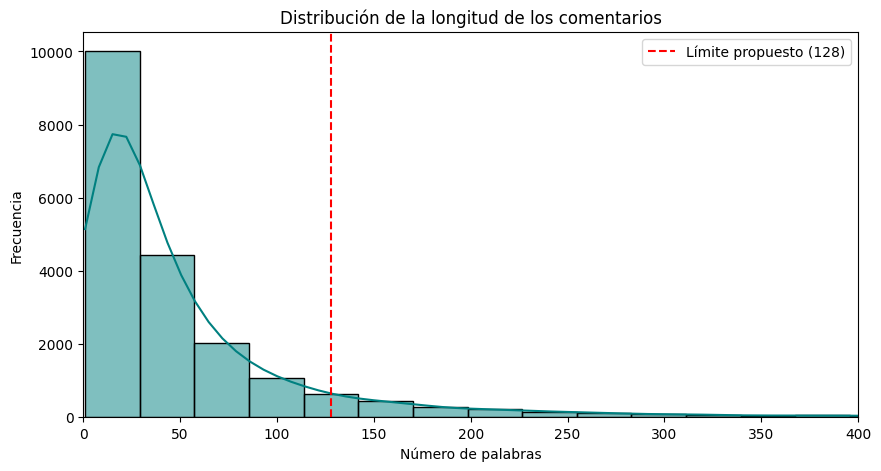

In [ ]:
# Calculamos la longitud en palabras de cada comentario
df_final['word_count'] = df_final['comment_text'].apply(lambda x: len(str(x).split()))

# Extraemos las estadísticas clave
media_palabras = df_final['word_count'].mean()
mediana_palabras = df_final['word_count'].median()
max_palabras = df_final['word_count'].max()

print("--- ESTADÍSTICAS DE LONGITUD (En palabras) ---")
print(f"Media de palabras:  {media_palabras:.1f}")
print(f"Mediana de palabras: {mediana_palabras:.1f}")
print(f"Máximo de palabras:  {max_palabras}")

# Calculamos qué porcentaje de comentarios tiene 128 palabras o menos
debajo_128 = (df_final['word_count'] <= 128).mean() * 100
print(f"Comentarios con <= 128 palabras: {debajo_128:.2f}%")

# Gráfico de distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_final['word_count'], bins=50, kde=True, color="teal")
# Añadimos una línea roja donde pondríamos nuestro límite de 128
plt.axvline(x=128, color='red', linestyle='--', label='Límite propuesto (128)')
plt.title("Distribución de la longitud de los comentarios")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.xlim(0, 400) # Recortamos la vista para evitar la "cola" de valores extremos
plt.legend()
plt.show()

Vemos que 128 representa el percentil 89.69, que es prácticamente un 90%. Decidimos ante esto fijar el límite de palabras a 128.

##  **¡Divide y vencerás!**

Separamos los datos en train y test. Sin olvidar que quereoms que las **clases estén bien representadas** en ambos conjuntos.

Al igual que antes usaremos `scikit-multilearn` conservando esta vez los dos conjuntos que nos devuelve la función `iterative_train_test_split`.

In [ ]:
from skmultilearn.model_selection import iterative_train_test_split

# Preparamos las matrices (skmultilearn requiere que X sea 2D)
X = df_final['comment_text'].values.reshape(-1, 1)
y = df_final[labels].values

# Forzamos la semilla de NumPy justo antes de la división
np.random.seed(42)
# División Estratificada Multietiqueta (80% / 20%)
X_train, y_train, X_test, y_test = iterative_train_test_split(X, y, test_size=0.20)

# Volvemos a dejar X como listas normales (1D) para el tokenizador
X_train = X_train.ravel().tolist()
X_test = X_test.ravel().tolist()

print("--- TAMAÑOS DE LOS CONJUNTOS ---")
print(f"Train: {len(X_train)} comentarios")
print(f"Test:  {len(X_test)} comentarios")

# COMPROBACIÓN
print("\n--- DISTRIBUCIÓN DE CLASES (Train vs Test) ---")
# Calculamos porcentajes en Train
porcentajes_train = (np.sum(y_train, axis=0) / len(y_train)) * 100
# Calculamos porcentajes en Test
porcentajes_test = (np.sum(y_test, axis=0) / len(y_test)) * 100

for i, etiqueta in enumerate(labels):
    print(f"{etiqueta:<15} | Train: {porcentajes_train[i]:.2f}%  | Test: {porcentajes_test[i]:.2f}%")

--- TAMAÑOS DE LOS CONJUNTOS ---
Train: 16000 comentarios
Test:  4000 comentarios

--- DISTRIBUCIÓN DE CLASES (Train vs Test) ---
toxic           | Train: 47.13%  | Test: 47.12%
severe_toxic    | Train: 4.91%  | Test: 4.92%
obscene         | Train: 26.04%  | Test: 26.02%
threat          | Train: 1.47%  | Test: 1.47%
insult          | Train: 24.27%  | Test: 24.27%
identity_hate   | Train: 4.33%  | Test: 4.32%


Vemos que las clases han sido perfectamente estratificadas. Ahora guardamos el conjunto test hasta el final, y posteriormente dividiremos el conjunto train en train y validación.

## **Construyendo el Transformer**

Crearemos el modelo basado en BERT. Vamos a combinar 3 bloques:
  * `BertTokenizer.from_pretrained(...)`
  * `TFBertModel.from_pretrained(...)`
  * Una **cabeza de clasificación** encima.

**Tips**:  
  - Hay que tomar decisiones sobre la longitud máxima de las secuencias.   
  - Hay que tokenizar los textos usando usando padding y truncado.  
  - `TFBertModel` no predice clases por sí mismo. Te da los emebeddings, y tú decides que hacer con ellos.  
  - Usaremos el embedding del token `[CLS]` como resumen de toda la frase.  
  - El encadenamiento de los tres bloques puedes realizarlo con la API funcional de Tensorflow.

Usamos **Keras** y la libería [KerasNLP](https://keras.io/examples/nlp/).

Esto se debe a que como proyecto de aprendizaje como es éste es el momento de probar cosas nuevas, experimentar y aprender. Me parece mucho desafiante y enriquecedor utilizar esta librería que no sabía ni que existía. El modelo y tokenizador Bert que usaremos son de **Google**



Instalamos la librería necesaria y nos aseguramos de que no haya compatibilidad de versiones 

In [ ]:
# Forzamos la instalación de versiones compatibles entre sí
!pip install -U tensorflow tensorflow-text keras-nlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.1 MB/s eta 0:00:00
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.26.0
    Uninstalling keras-hub-0.26.0:
      Successfully uninstalled keras-hub-0.26.0
  Attempting uninstall: keras-nlp
    Found existing installation: keras-nlp 0.26.0
    Uninstalling keras-nlp-0.26.0:
      Successfully uninstalled keras-nlp-0.26.0


Construimos el modelo usando keras / tensorflow y sacando tanto el tokenizador Bert (`BertTokenizer`) como el modelo (`BertBackbone`) de la librería `KerasNLP`. Como dijimos queremos que la longitud máxima sea 128. El tokenizador directamente trunca y rellena (hace *padding*) donde es necesario.

In [ ]:
import tensorflow as tf
import keras
import keras_nlp

# Configuración
MAX_LEN = 128


# # Tokenizador (Padding y Truncado gestionado aquí)
# tokenizer = keras_nlp.models.BertTokenizer.from_preset(
#     "bert_base_en_uncased",
#     sequence_length=MAX_LEN
# )

# Backbone (Carga el modelo)
backbone = keras_nlp.models.BertBackbone.from_preset("bert_base_en_uncased")

# Construcción del modelo funcional
def build_robust_model():
    # Definimos los inputs (KerasTensors)
    input_ids = keras.layers.Input(shape=(MAX_LEN,), dtype="int32", name="input_ids")
    padding_mask = keras.layers.Input(shape=(MAX_LEN,), dtype="int32", name="padding_mask")


    # Esto genera los segment_ids simbólicos que KerasNLP exige
    segment_ids = keras.ops.zeros_like(input_ids)

    # Pasamos los inputs al backbone
    bert_outputs = backbone({
        "token_ids": input_ids,
        "padding_mask": padding_mask,
        "segment_ids": segment_ids
    })

    # Extraemos el CLS token (pooled_output)
    cls_token = bert_outputs["pooled_output"]

    # Capa Dropout (Regularización)
    x = keras.layers.Dropout(0.3)(cls_token)

    # Cabeza de clasificación
    outputs = keras.layers.Dense(6, activation="sigmoid", name="classifier")(x)

    # Modelo Funcional
    model = keras.Model(
        inputs=[input_ids, padding_mask],
        outputs=outputs,
        name="bert_classifier"
    )

    return model

# Instanciación y Compilación
model = build_robust_model()

# Definimos las métricas
# Usamos 'macro' para que las clases minoritarias pesen lo mismo que las mayoritarias
f1_metric = keras.metrics.F1Score(average='macro', threshold=0.5, name='f1_score')
auc= keras.metrics.AUC(multi_label=True, num_labels=6, name='auc_media'
)

# Compilamos
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=[f1_metric, 'accuracy',auc] # Mantenemos accuracy para ver la comparación
)

model.summary()

100%|██████████| 457/457 [00:00<00:00, 1.14MB/s]


100%|██████████| 418M/418M [00:09<00:00, 44.2MB/s]


Model: "bert_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 128)       │          0 │ input_ids[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 109,482,2… │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 128, 768)] │            │ zeros_like[0][0], │
│                     │                   │            │ input_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 768)       │          0 │ bert_backbone[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 6)         │      4,614 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,486,854 (417.66 MB)

 Trainable params: 109,486,854 (417.66 MB)

 Non-trainable params: 0 (0.00 B)

Procedemos aquí a explicar lo que hemos hecho en esta última celda.

*   Hemos llamado al tokenizador (**actualización:** en realidad no lo usamos aquí, vamos a preprocesar el texto antes del entrenamiento) y al modelo Bert (recordamos que esto **No clasifica**), la idea es que como estamos cogiendo un modelo gigantesco entrenado hacerle *fine tuning* con nuestros datos, que será pan comido para un mega transformer como este
*  Tras la salida del modelo Bert, recuperamos el token [CLS] que resume el contexto de toda el comentario (a través del mecanismo de atención "mira" a todas las demás palabras de la frase y actúa como un resumen matemático global). Este token es el que pasamos por el clasificador, que en nuestro caso en vez de usar la función `softmax` como se suele usar usamos la función `sigmoide` pues cada clase es independiente de las otras (no queremos que las probabilidades sumen 1) y se dará como clasificado en esa clase si la probabilidad es mayor de 0.5 por defecto.



*   Uso de **F1-score macro** que es la media de todas las F1-score clase a clase (pues el modelo está muy desbalanceado) y **entropía cruzada binaria** pues al estar en un contexto multietiqueta queremos que cada clase sea independiente. La entropía cruzada binaria trata el problema como 6 (porque hay 6 clases) pequeños problemas de Verdadero/Falso simultáneos, que es lo que queremos.
*   Se añade *dropout* como regularización, que en estos modelos es prácticamente obligatorio.





##  **Entrenamiento**

Aquí empieza el verdadero drama del Deep Learning: decidir cuántas muestras va a ver de golpe `batch_size`, con qué rapidez va a aprender `learning_rate`, y cuándo parar para no liarla `early_stopping`.

En esta sección hay que:

* Elegir bien los hiperparámetros.


* Controlar el sobreajuste. Si el modelo acierta todo en entrenamiento pero falla en validación... mal asunto. Pruebamos a:

    - Usar Dropout

    - Subir el batch_size

    - Afinar el learning_rate

Para realizar el entrenamiento dividimos el conjunto train en train y validación de forma estratificada. Como estamos haciendo *fine tuning* tomamos solo 2 mil ejemplos de validación, que serán más que suficientes

In [ ]:
# Partimos de los 16.000 que ya separamos en la Tarea 3 (X_train, y_train)
# Queremos sacar un 12.5% de esos 16.000 para validación (que equivalen al 10% del total original)

# Preparamos las matrices
X_train_np = np.array(X_train).reshape(-1, 1) # X_train es lista, lo pasamos a array 2D
y_train_np = np.array(y_train)

# Split Estratificado Iterativo (Train -> Train_final + Val)
# test_size=0.125 porque 0.125 * 16.000 = 2.000 ejemplos
X_train_final, y_train_final, X_val, y_val = iterative_train_test_split(
    X_train_np,
    y_train_np,
    test_size=0.125
)

# Convertimos de vuelta a listas para el tokenizador
train_texts_final = X_train_final.ravel().tolist()
val_texts = X_val.ravel().tolist()

train_labels_final = y_train_final.tolist()
val_labels = y_val.tolist()

print(f"Entrenamiento final: {len(train_texts_final)} ejemplos")
print(f"Validación: {len(val_texts)} ejemplos")

# Verificación de integridad
# Esto comprueba que la distribución de la clase minoritaria se mantiene
porcentajes_train = (np.sum(y_train_final, axis=0) / len(y_train_final)) * 100
porcentajes_val = (np.sum(y_val, axis=0) / len(y_val)) * 100

print("\nVerificación de estratificación (Train vs Val):")
for i, etiqueta in enumerate(labels):
    print(f"{etiqueta:<15} | Train: {porcentajes_train[i]:.2f}% | Val: {porcentajes_val[i]:.2f}%")

Entrenamiento final: 14000 ejemplos
Validación: 2000 ejemplos

Verificación de estratificación (Train vs Val):
toxic           | Train: 47.13% | Val: 47.15%
severe_toxic    | Train: 4.91% | Val: 4.90%
obscene         | Train: 26.04% | Val: 26.05%
threat          | Train: 1.46% | Val: 1.60%
insult          | Train: 24.28% | Val: 24.25%
identity_hate   | Train: 4.33% | Val: 4.35%


Realmente sobre la marcha se ha decidido llamar al **Preprocesador Bert**, en lugar de solo al tokenizer y hacer el preprocesamiento fuera del entrenamiento en sí. De esta forma se realiza una vez y ya está, haciendo que el entrenamiento sea más ligero, si lo pusieramos como una primera capa del modelo habría que hacerlo una y otra vez y dentro del propio entrenamiento. Por tanto, lo hacemos fuera antes de entrenarlo.

In [ ]:
# Definimos el preprocesador
# El preprocesador hace: Tokenizar + Padding + Truncado + Máscaras
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=128
)

# Procesamos los datos (esto  devuelve un diccionario)
train_encodings = preprocessor(train_texts_final)
val_encodings = preprocessor(val_texts)



Por último, definimos los callbacks como `Early Stopping`, para evitar el sobreajuste. Al ser un modelo tan potente, en una primera instancia el modelo con 6 epochs sobreajustó, decimos añadir también el callback que reduce el learning rate de forma iterativa `ReduceLROnPlateau`.

Para controlar el sobreajuste usaremos `livelossplot` para que pinte las gráficas de la loss

In [ ]:
!pip install livelossplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.8/627.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not cu

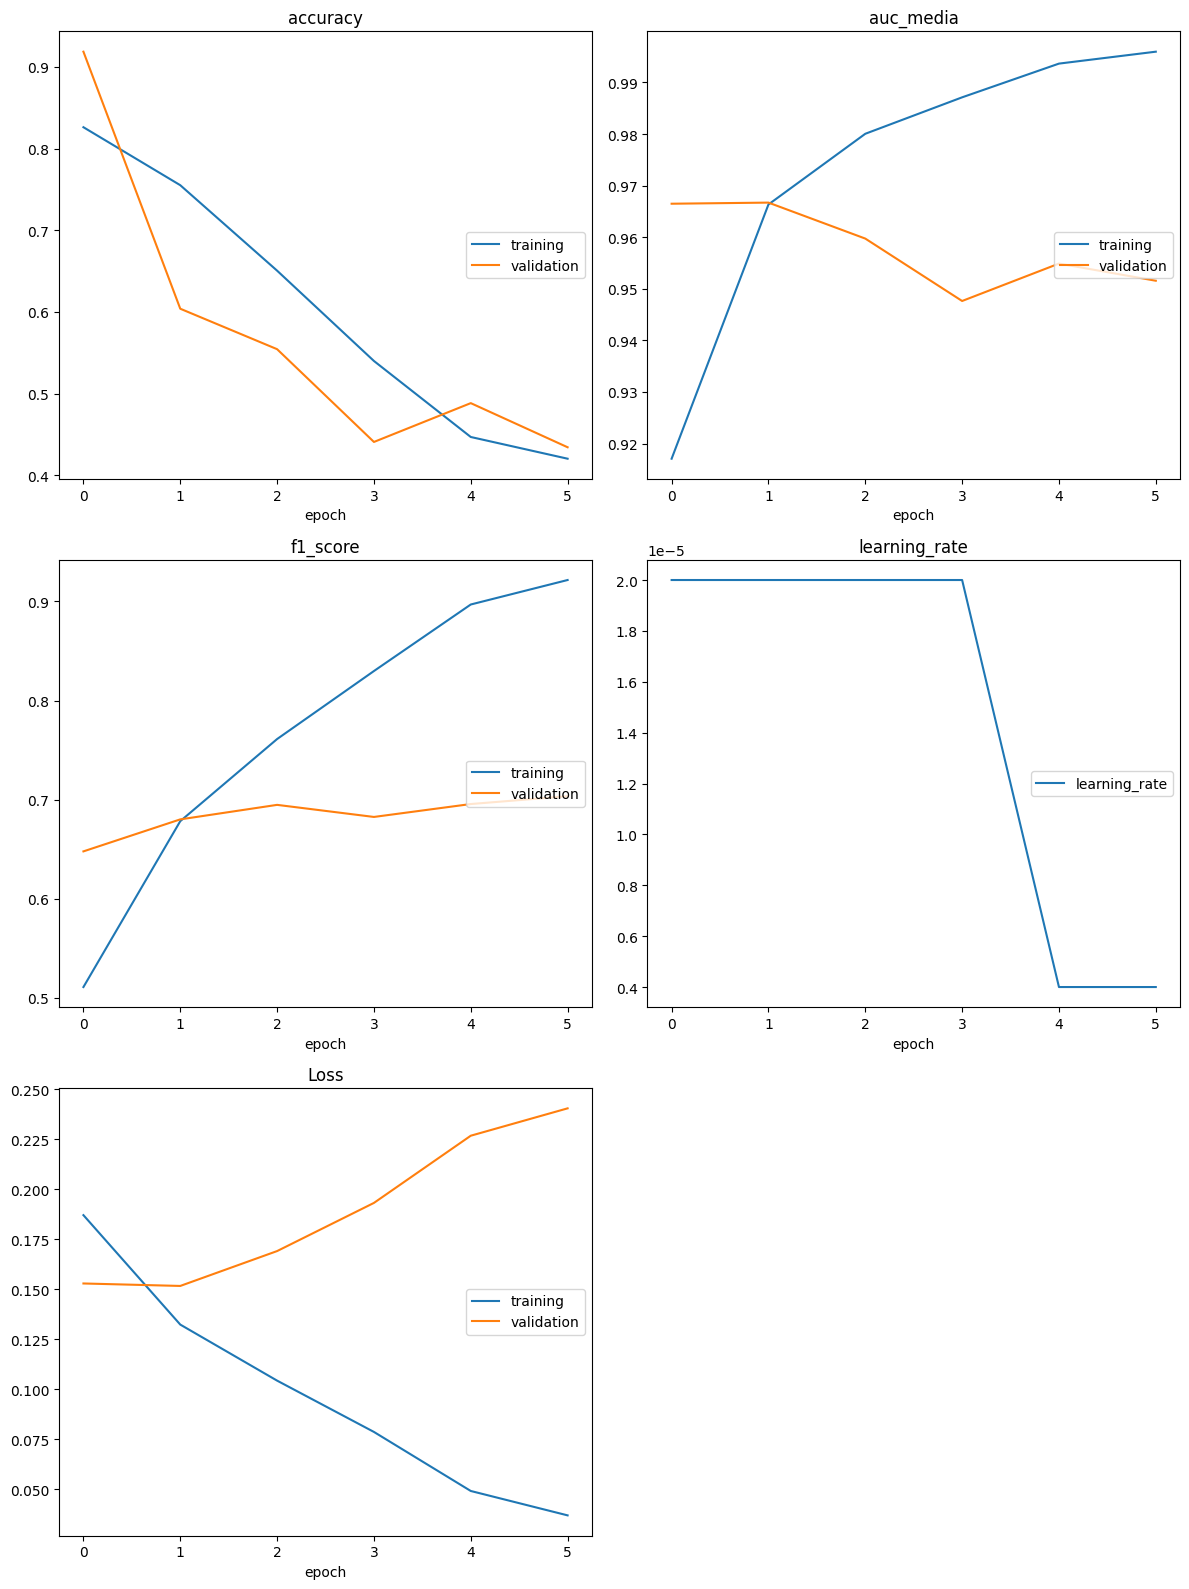

accuracy
	training         	 (min:    0.421, max:    0.826, cur:    0.421)
	validation       	 (min:    0.435, max:    0.919, cur:    0.435)
auc_media
	training         	 (min:    0.917, max:    0.996, cur:    0.996)
	validation       	 (min:    0.948, max:    0.967, cur:    0.952)
f1_score
	training         	 (min:    0.511, max:    0.922, cur:    0.922)
	validation       	 (min:    0.648, max:    0.703, cur:    0.703)
learning_rate
	learning_rate    	 (min:    0.000, max:    0.000, cur:    0.000)
Loss
	training         	 (min:    0.037, max:    0.187, cur:    0.037)
	validation       	 (min:    0.152, max:    0.241, cur:    0.241)
875/875 ━━━━━━━━━━━━━━━━━━━━ 395s 451ms/step - accuracy: 0.4205 - auc_media: 0.9960 - f1_score: 0.9217 - loss: 0.0369 - val_accuracy: 0.4345 - val_auc_media: 0.9516 - val_f1_score: 0.7034 - val_loss: 0.2405 - learning_rate: 4.0000e-06
Restoring model weights from the end of the best epoch: 6.


In [ ]:

from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from livelossplot import PlotLossesKeras

# Crear el callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Qué métrica estamos vigilando
    factor=0.2,           # Por cuánto multiplicamos el LR actual (ej. 0.001 * 0.2)
    patience=2,           # Cuántas épocas esperamos sin mejora antes de actuar
    min_lr=1e-6,          # El límite mínimo (para que no se haga literalmente 0)
    verbose=1             # Para que te imprima un mensaje cuando actúe
)

# Callbacks
# Guardar el modelo solo cuando el F1-Score en validación mejora
checkpoint =ModelCheckpoint(
    'best_model.keras', monitor='val_f1_score', save_best_only=True, mode='max'
)

# Detener si después de 2 épocas no mejora el F1-Score
early_stopping = EarlyStopping(
    monitor='val_f1_score', patience=3, mode='max',restore_best_weights=True, verbose=1
)

plotlosses = PlotLossesKeras()

# Creamos el Dataset de Entrenamiento
# Esto empaqueta (inputs, labels) de forma que Keras entiende perfectamente
# Ya se indica aquí la separación por batches, importante que en train hay
# ir cambiandolos para que no sean siempre los mismos. En validation da igual
train_ds = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": train_encodings["token_ids"],
        "padding_mask": train_encodings["padding_mask"]
    },
    train_labels_final
)).shuffle(buffer_size=10000).batch(16).prefetch(tf.data.AUTOTUNE)

# Creamos el Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": val_encodings["token_ids"],
        "padding_mask": val_encodings["padding_mask"]
    },
    val_labels
)).batch(16).prefetch(tf.data.AUTOTUNE)

# Lanzamos el entrenamiento con los datasets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[checkpoint, early_stopping,reduce_lr,plotlosses]
)

El modelo parece que ha aprendido bastante, pues da como resultado un F1-score que no está nada mal. Veamos la evaluación en el conjunto de validación. Parece que el modelo sigue sobreajustando a pesar las "mejoras" que le hemos añadido, viendo las gráficas diríamos que la epoch 1 o 2 han sido las mejores, el modelo se queda con la 6 porque es la que más F1-score alcanza.

**Posibles formas de evitar el sobreajuste**: Partiendo de los mismos callbacks, podríamos usar la métrica AUC en lugar de la F1-score pues es más flexible (ya que el F1-score depende de un umbral y AUC no) y con el modelo entrenado de está forma, ya buscar el umbral óptimo de cada clase para obtener un mayor F1-score. Supongo que reconocer los errores y saber qué se podría mejorar es igual de formativo que ejecutar de esa forma la experimentación.


También hemos impreso las medias de las AUC de cada clase, pues es lo que usaba el concurso de Kaggle del que provienen los datos como métrica.

Hemos usado batches de 16, pues 8 haría que el modelo fuese más lento (y en colab gratuito no es que tengamos horas de sobra ya que con 16 ha tardado  unos 35 minutos aprox.) y por el contrario, aunque con 32 pudiera ir más rápido quizás era demasiada información de golpe para la GPU. Además de que un batch_size de 16 introduce un **efecto regularizador** ya que añade un poco más de "ruido" o "nerviosismo" en la dirección en la que el modelo actualiza sus pesos en cada paso, comparado con 32. Ese ruido ayuda al modelo a no quedarse atascado en mínimos locales pobres. Obliga al modelo a generalizar mejor el lenguaje tóxico en lugar de memorizar ejemplos concretos.

Veamos en profundidas los resultados del modelo en el conjunto de validación

125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 118ms/step
--- REPORT DE CLASIFICACIÓN (VALIDACIÓN) ---
               precision    recall  f1-score   support

        toxic       0.84      0.94      0.89       943
 severe_toxic       0.45      0.60      0.52        98
      obscene       0.79      0.88      0.83       521
       threat       0.59      0.72      0.65        32
       insult       0.71      0.81      0.76       485
identity_hate       0.53      0.63      0.58        87

    micro avg       0.76      0.87      0.81      2166
    macro avg       0.65      0.76      0.70      2166
 weighted avg       0.77      0.87      0.81      2166
  samples avg       0.40      0.43      0.40      2166



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


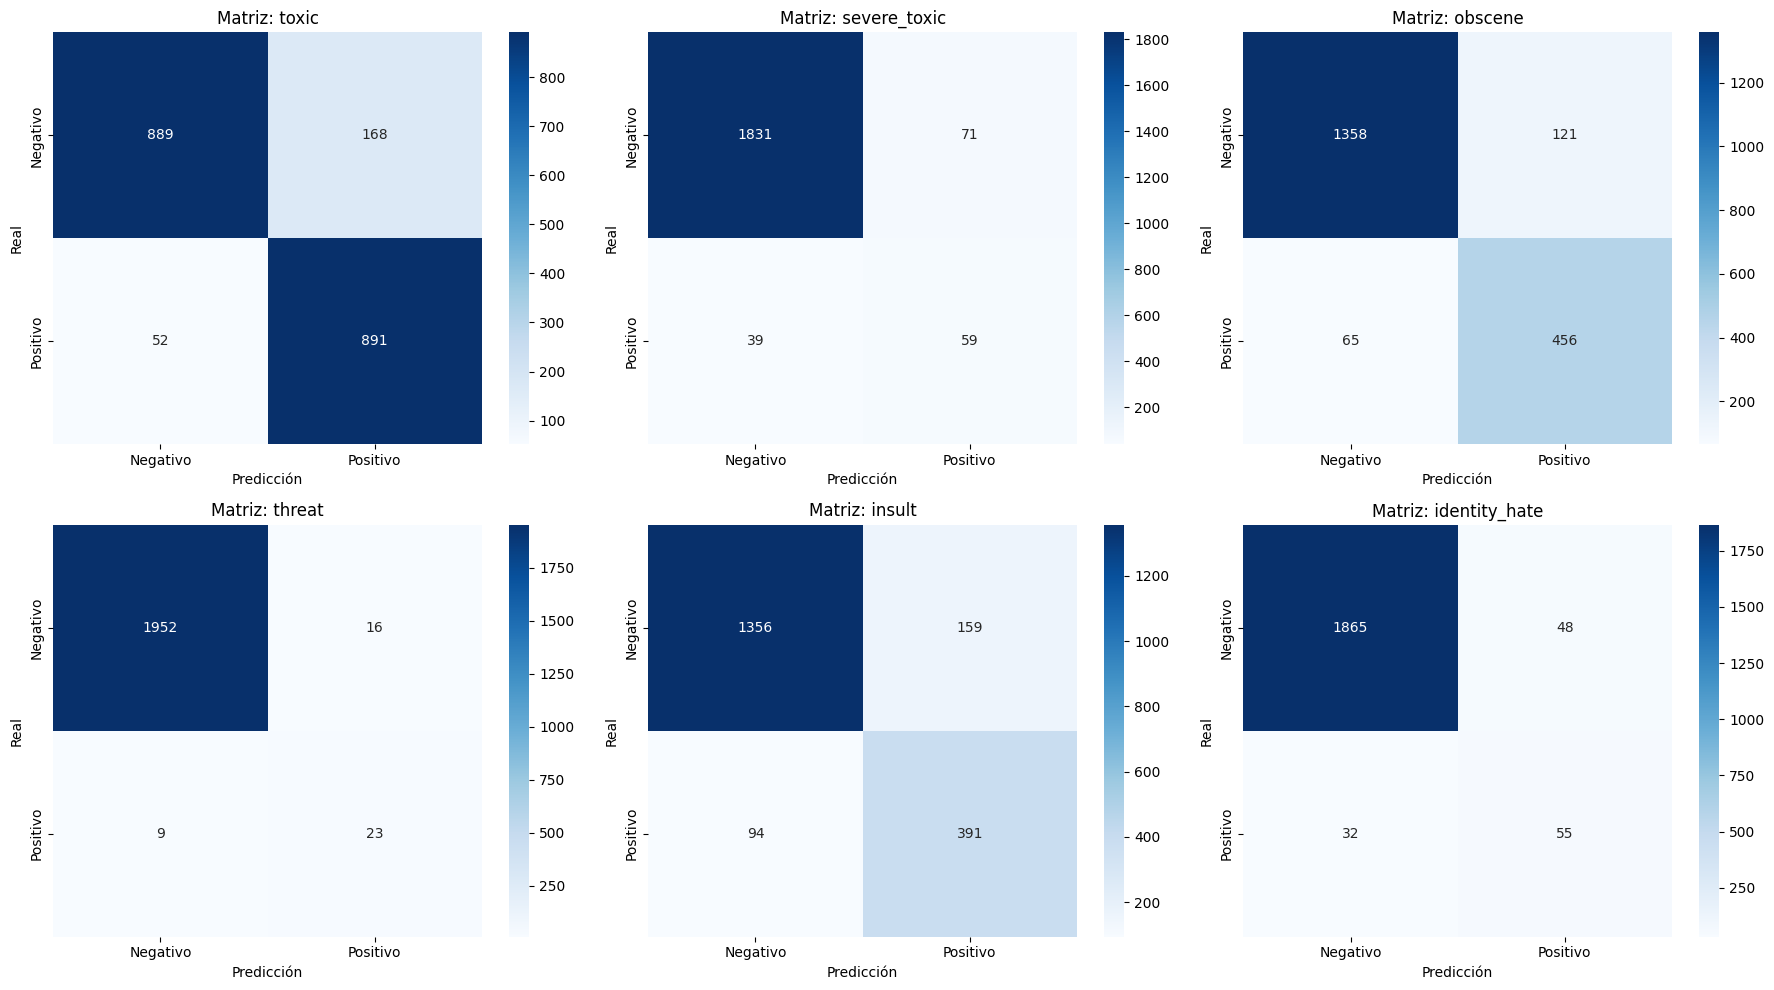

In [ ]:
# Obtener las predicciones usando el dataset
# Esto devolverá las probabilidades (n_muestras, 6)
y_pred_probs = model.predict(val_ds)

# Convertir a binario (umbral 0.5)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Obtener las etiquetas reales (Ground Truth)
# Como ya tenemos 'val_labels' en memoria las usamos directamente.
y_true = np.array(val_labels)

# Reporte de Clasificación General
print("--- REPORT DE CLASIFICACIÓN (VALIDACIÓN) ---")
print(classification_report(y_true, y_pred_binary, target_names=labels))

# Matrices de Confusión (Clase a clase)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, label in enumerate(labels):
    # Matriz para la clase i-ésima
    cm = confusion_matrix(y_true[:, i], y_pred_binary[:, i])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])

    axes[i].set_title(f'Matriz: {label}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

Al ser multietiqueta, consideramos las matrices de confusión clase a clase es decir, se tiene solo en cuenta los aciertos y fallos en esa clase y se ignoran los demás.

Como podemos ver, las clases de las que hay más datos se clasifican mejor. Sin embargo, las clases minoritarias tienen peor rendimiento.

Para consideraciones futuras, se podrían tomar más datos de las clases minoritarias (nuestro muestreo ha sido estratificado) o se podrían poner pesos personalizados para que "un error en una clase minoritaria duela más", intentando que el modelo se esfuerce más por aprender estas.

## Evaluación

Momento de la verdad!
Con el modelo entrenado, ya aprendido (esperemos), y ahora toca ver cómo se comporta con datos que no ha visto nunca.

En esta parte:

* Se evalúa el modelo sobre el conjunto de test.

* Se representa las curvas de entrenamiento y validación (accuracy y loss) para ver si ha habido sobreajuste, infrajuste… .

* Se comentan brevemente los resultados: ¿ha aprendido bien? ¿hay alguna clase que le cueste más?

In [ ]:
# Para el preprocessor
test_texts = X_test
test_labels = y_test.tolist() # Aseguramos que sea una lista plana de strings
         # Aseguramos que sea un array numérico



In [ ]:
# Tokenización (usando el mismo preprocessor que en train/val)
test_encodings = preprocessor(test_texts)

# Creación del Dataset de Test
test_ds = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": test_encodings["token_ids"],
        "padding_mask": test_encodings["padding_mask"]
    },
    test_labels
)).batch(16).prefetch(tf.data.AUTOTUNE)

print("Test dataset preparado.")

Test dataset preparado.


250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step
--- REPORT DE CLASIFICACIÓN (TEST FINAL) ---
               precision    recall  f1-score   support

        toxic       0.86      0.95      0.90      1885
 severe_toxic       0.45      0.55      0.50       197
      obscene       0.79      0.88      0.84      1041
       threat       0.60      0.53      0.56        59
       insult       0.74      0.80      0.77       971
identity_hate       0.56      0.62      0.59       173

    micro avg       0.78      0.86      0.82      4326
    macro avg       0.67      0.72      0.69      4326
 weighted avg       0.78      0.86      0.82      4326
  samples avg       0.40      0.43      0.40      4326



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


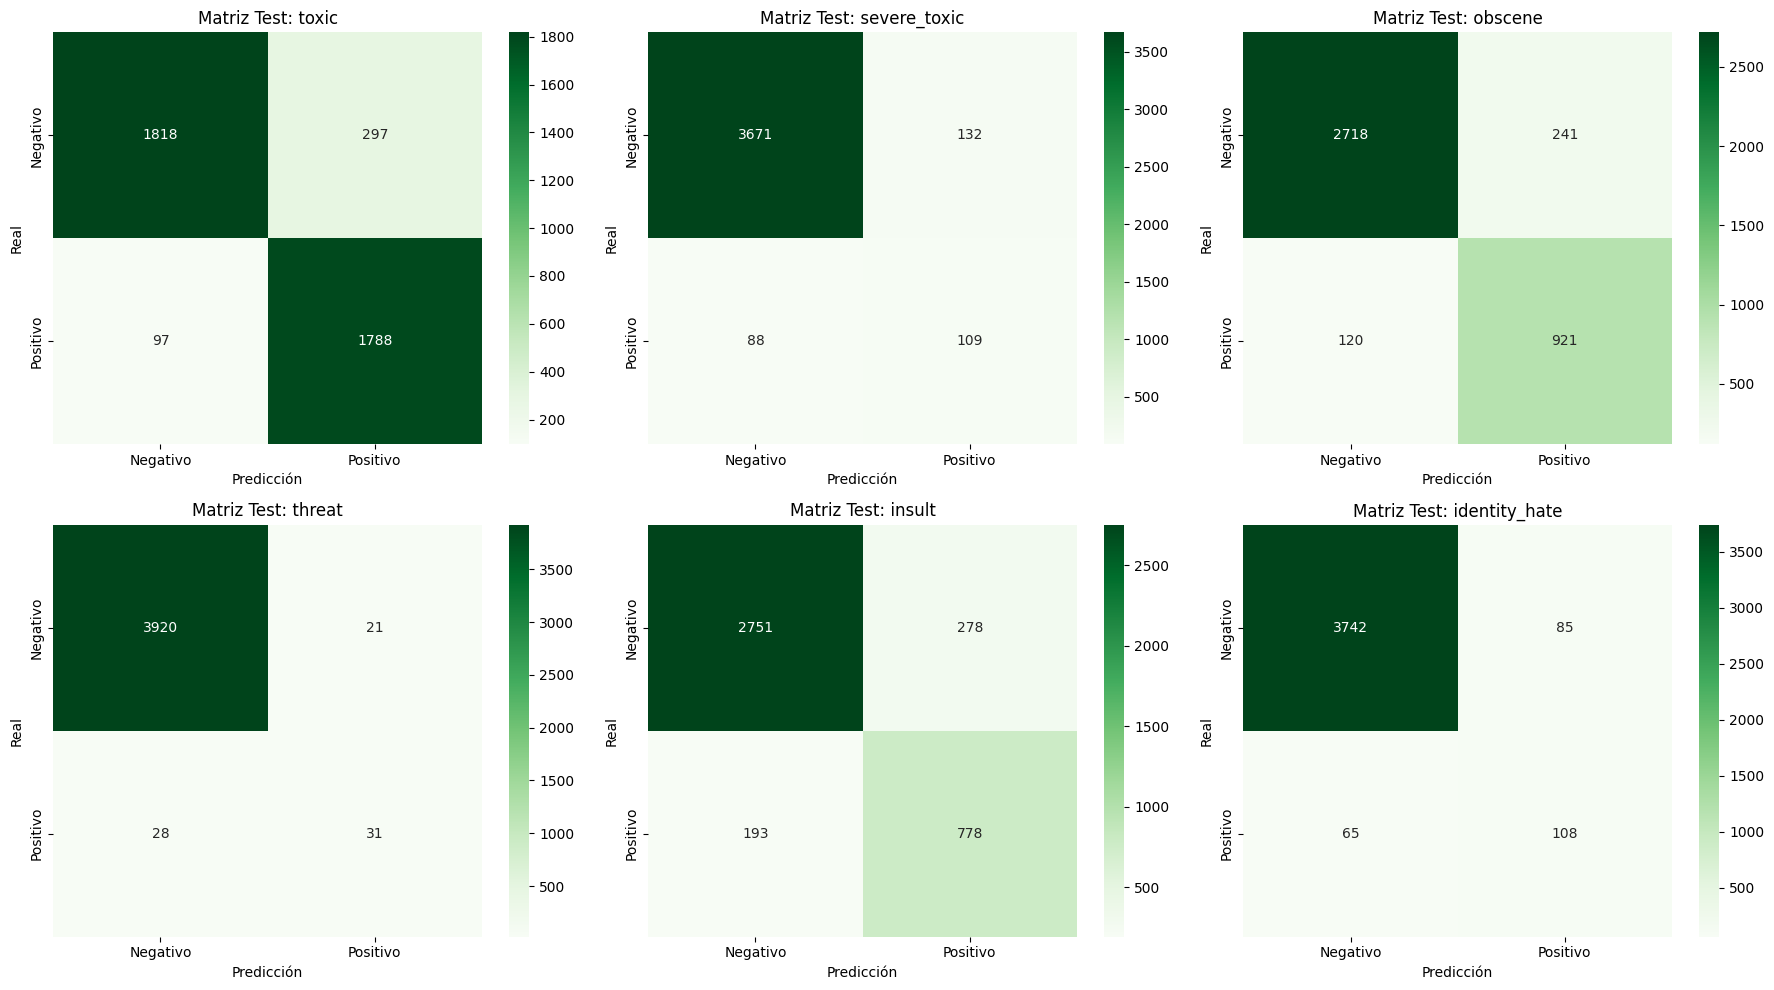

In [ ]:
# Predecir
y_pred_probs_test = model.predict(test_ds)

# Binariar
y_pred_binary_test = (y_pred_probs_test > 0.5).astype(int)

# Reporte de Clasificación Final
print("--- REPORT DE CLASIFICACIÓN (TEST FINAL) ---")
print(classification_report(test_labels, y_pred_binary_test, target_names=labels))


# Convertimos a arrays de NumPy explícitamente
y_true_np = np.array(test_labels)
y_pred_np = np.array(y_pred_binary_test)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, label in enumerate(labels):
    # Usamos arrays de numpy
    cm = confusion_matrix(y_true_np[:, i], y_pred_np[:, i])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])

    axes[i].set_title(f'Matriz Test: {label}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

Vemos que el rendimiento es similar al del conjunto de validación, así que  es el resultado que se esperaba. Las clases más minoritarias son las que se predicen peor y tienen un F1-score más bajo.

Sacamos también la media de las AUC por clase ya que es una medida más robusta. Mientras que el F1-score depende del umbral elegido (con otro umbral podría salir un mejor valor), el AUC trabaja con las probabilidades "crudas", es decir no depende de ningún umbral de decisión.

In [ ]:

def calculate_auc_metrics(y_true, y_pred_probs, class_names):
    """
    Calcula el AUC por clase y la media (Kaggle score)
    """
    # AUC por cada clase
    auc_scores = {}
    for i, name in enumerate(class_names):
        score = roc_auc_score(y_true[:, i], y_pred_probs[:, i])
        auc_scores[name] = score

    # Media (Mean Columnwise ROC AUC)
    mean_auc = np.mean(list(auc_scores.values()))

    return auc_scores, mean_auc

# --- APLICACIÓN ---

# Nombres de tus etiquetas
labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Evaluación en Validación
val_probs = model.predict(val_ds) # Probabilidades crudas del modelo
val_auc_per_class, val_mean_auc = calculate_auc_metrics(np.array(val_labels), val_probs, labels)

# Evaluación en Test
test_probs = model.predict(test_ds)
test_auc_per_class, test_mean_auc = calculate_auc_metrics(np.array(test_labels), test_probs, labels)

# --- RESULTADOS ---
print("--- AUC POR CLASE (VALIDACIÓN) ---")
for k, v in val_auc_per_class.items(): print(f"{k}: {v:.4f}")
print(f"\nSCORE FINAL VAL (Mean AUC): {val_mean_auc:.4f}\n")

print("--- AUC POR CLASE (TEST) ---")
for k, v in test_auc_per_class.items(): print(f"{k}: {v:.4f}")
print(f"\nSCORE FINAL TEST (Mean AUC): {test_mean_auc:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step
--- AUC POR CLASE (VALIDACIÓN) ---
toxic: 0.9538
severe_toxic: 0.9490
obscene: 0.9596
threat: 0.9900
insult: 0.9348
identity_hate: 0.9650

SCORE FINAL VAL (Mean AUC): 0.9587

--- AUC POR CLASE (TEST) ---
toxic: 0.9547
severe_toxic: 0.9534
obscene: 0.9604
threat: 0.9748
insult: 0.9383
identity_hate: 0.9555

SCORE FINAL TEST (Mean AUC): 0.9562


Considerando que el máximo del AUC es 1, vemos que tenemos en general modelos con un buen rendimiento, ajustando el umbral de cada clase podríamos tener un F1-score bastante más elevado y quizás se hubiera refinado todo un poco más usando el AUC como métrica de entrenamiento.

##  Reflexión final


A modo de reflexión recapitulamos aquí todo a lo que nos hemos enfrentado en este trabajo, lo que ha salido bien, lo que ha salido mal y además lo que se podría haber mejorado.

Hemos empezado la tarea eligiendo un **dataset** bastante interesante en mi opinión, tanto por la naturaleza del mismo al ser comentarios tóxicos como por ser un problema de multietiqueta al no haberme enfrentado a un problema así nunca.

Explorando los datos vimos que las clases estaban desbalanceadas y parecía haber una superclase. También definimos la longitud límite de los comentarios.

Así nos adentramos en la parte dura del trabajo, se usa la librería **KerasNLP** explorando una librería nueva y pudiendo usar Keras.

El **entrenamiento** no ha sido tan duro, pero al tardar más de media hora en entrenar no teníamos intentos ilimitados. Para evitar el sobreajuste se implementan varios callbacks, aun así finalmente parece que ha acabado sobreajustando, pero no es nada preocupante. Luego **evaluamos** en validation y test viendo que se otienen prácticamente los mismo resultados, cosa que es buena señal. Las clases minoritarias son las que peores resultados dan, pero para la ínfima cantidad de ejemplos que hemos tomado comparado con el total hemos tenido unos resultados más que satisfactorios. De forma concreta, hemos obtenido en el conjunto test un AUC medio  0.9562, siendo 1 una puntación perfecta. Aunque los resultados sean buenos teniendo en cuenta que hemos usado 20 mil ejemplos de 160 mil disponibles, que representan un 12.5% del total,  hay que ser críticos y analizar también otras opciones y cosas que se podrían haber hecho distintas.



*   **Muestro igualitario del dataset**: En lugar de tomar una muestra manteniendo las proporciones originales de los datos tóxicos, al haber tantos datos en el dataset, podríamos haber tomado la misma cantidad de datos de todas las clases (siempre que fuera posible, porque por ejemplo de amenazas solo había 478 ejemplos en total). Es decir, podríamos haber intentado balancear el dataset de forma artificial, al menos en la medida dentro de lo posible, aprovechando que estamos tomando menos datos del total
*   **Uso de la variable *toxic* como una superclase**: Como se dijo, seguramente esa variable sería una superclase aunque no la hayamos tenido en cuenta como tal. Para aprovechar esto se podrían construir dos modelos, uno que simplemente diga si un mensaje es toxico o sano (diferenciar la superclase) y luego otro que sabiendo que los mensajes son toxicos, los clasifique según sus tipo de toxicidades.

* **Uso de pesos ponderados**: Para dataset desbalanceados que no son capaces de aprender bien clases minoritarias, una técnica que se suele usar es implementar pesos ponderados por clases. Esto se hace para que un error en una clase minoritaria "duela más". No la he implementado porque ya la usado en varios proyectos, no suponía ningún tipo de desafío y no creo que fuera el objetivo del proyecto.

* **Uso de AUC como métrica para entrenar y búsqueda del mejor umbral**: Como el dataset está desbalanceado hemos usado como métrica de entrenamiento el F1-score, esto quizás ha sido un error pues al depender de un umbral fijo es menos flexible. Otras métricas como la media del AUC por clase o la propia loss sí que son más flexibles pues no dependen de parámetros fijos. Lo ideal hubiera sido evaluar por el AUC y luego ajustar el umbral que maximiza el F1-score para cada clase, dando luegar así a los mejores resultados posibles. No se ha hecho pues la diferencia a nivel código es mínima, los resultados del AUC ya son bastante buenos así y habría que esperar (una vez más) un buen rato a que entrene el modelo. Se queda como posible mejora


Como **conclusión** puedo afirmar de que se me ha quedado un buen sabor de boca con este proyecto pues a pesar de que era desde 0 y las dificultades añadidas que han surgido, creo que he conseguido superar los retos, obtener unos datos decentes y sobre todo aprender de esta experiencia.
